In [1]:
# this section works!!!!
# USE this part !!!!

import yt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

d1 = "/Users/potato/Downloads/plt59250"
#d1 = '/home/u0890475/Downloads/plt59250'
ds = yt.load(d1)

ds.force_periodicity()
ds.add_gradient_fields(("boxlib", "Y(H2)"))

Tkey = ("boxlib", "temp")
mass_fields = [f for f in ds.field_list if "Y(" in f[1]]

# fields we will load per grid
grad_keys = [
    ("boxlib", "Y(H2)_gradient_x"),
    ("boxlib", "Y(H2)_gradient_y"),
    ("boxlib", "Y(H2)_gradient_z"),
]

# Collect chunks here
chunks = []

# Loop over AMR grid patches (memory-safe)
for g in ds.index.grids:
    # Quick reject: if this grid is entirely to the right of x=0.07, skip it
    if float(g.LeftEdge[0]) >= 0.07:
        continue

    # Pull minimal fields first (to build mask cheaply)
    x = g[("index", "x")].ndarray_view().ravel()
    T = g[Tkey].ndarray_view().ravel()

    mask = (T > 310.0) & (x < 0.07)
    if not np.any(mask):
        continue

    # Now pull only what you need (still per-grid, so small)
    y  = g[("index", "y")].ndarray_view().ravel()
    z  = g[("index", "z")].ndarray_view().ravel()
    dx = g[("index", "dx")].ndarray_view().ravel()

    gh2x = g[grad_keys[0]].ndarray_view().ravel()
    gh2y = g[grad_keys[1]].ndarray_view().ravel()
    gh2z = g[grad_keys[2]].ndarray_view().ravel()
    gh2mag = np.sqrt(gh2x*gh2x + gh2y*gh2y + gh2z*gh2z)

    data = {
        "x": x[mask],
        "y": y[mask],
        "z": z[mask],
        "T": T[mask],
        "gridsize": dx[mask],
        "gh2x": gh2x[mask],
        "gh2y": gh2y[mask],
        "gh2z": gh2z[mask],
        "gh2mag": gh2mag[mask],
    }

    # mass fractions (only masked cells)
    for f in mass_fields:
        data[f[1]] = g[f].ndarray_view().ravel()[mask]

    chunks.append(pd.DataFrame(data))

# Final dataframe
if len(chunks) == 0:
    raise RuntimeError("No cells found for (T>350) & (x<0.07).")

df_350 = pd.concat(chunks, ignore_index=True)
print("df_350 shape:", df_350.shape)
print(df_350.head())



yt : [INFO     ] 2026-02-25 09:56:54,213 Parameters: current_time              = 0.1696800000000185
yt : [INFO     ] 2026-02-25 09:56:54,213 Parameters: domain_dimensions         = [384  64  64]
yt : [INFO     ] 2026-02-25 09:56:54,214 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2026-02-25 09:56:54,214 Parameters: domain_right_edge         = [0.105  0.0175 0.0175]


df_350 shape: (176568, 18)
          x         y         z           T  gridsize       gh2x      gh2y  \
0  0.069590  0.000137  0.000137  327.034197  0.000273 -11.422267  1.920706   
1  0.069590  0.000137  0.000410  313.098243  0.000273  -7.251249  2.712254   
2  0.069590  0.000410  0.000137  315.303855  0.000273 -10.428595  2.450517   
3  0.069863  0.000137  0.000137  683.491606  0.000273 -16.079777  2.367719   
4  0.069863  0.000137  0.000410  538.985508  0.000273 -14.652656  5.718231   

        gh2z     gh2mag          Y(H)     Y(H2)    Y(H2O)   Y(H2O2)    Y(HO2)  \
0  -2.810761  11.918795  2.223470e-10  0.010028  0.012681  0.000077  0.000029   
1   4.724278   9.069494  8.897121e-11  0.011503  0.003061  0.000019  0.000011   
2  -1.279848  10.788820  4.813765e-11  0.010763  0.009844  0.000062  0.000021   
3  -8.109910  18.164140  2.189860e-05  0.005784  0.062257  0.000138  0.000237   
4  10.437974  18.877230  6.601603e-06  0.008605  0.022043  0.000069  0.000188   

      Y(N2)      

In [2]:
"""
import yt
import numpy as np
import pandas as pd

#d1 = "/Users/potato/Downloads/plt59250"
d1 = '/home/u0890475/Downloads/plt59250'
ds = yt.load(d1)

ds.force_periodicity()
ad = ds.all_data()
x = ad[("index","x")].ndarray_view()
y = ad[("index","y")].ndarray_view()
z = ad[("index","z")].ndarray_view()

x_unique = np.unique(x)
y_unique = np.unique(y)
z_unique = np.unique(z)

print("Nx =", len(x_unique))
print("Ny =", len(y_unique))
print("Nz =", len(z_unique))
"""
df_out = df_350.copy()
df_350_c = df_350.copy()
df_350_c = df_350_c.sort_values(by=['x','y','z']).reset_index(drop=True)
x_cold_region = df_out['x'].min()-0.003
print(x_cold_region)

df_


0.06259082031249999


In [47]:
for g in ds.index.grids:
    # Quick reject: if this grid is entirely to the right of x=0.07, skip it
    if float(g.LeftEdge[0]) >= 0.07:
        continue

    # Pull minimal fields first (to build mask cheaply)
    x = g[("index", "x")].ndarray_view().ravel()
    T = g[Tkey].ndarray_view().ravel()


    """
    Just cut the region at the boundary of isothermal wall x=0.07
    If need to find points of flame at isothermal wall, make sure set the value larger than 0.07 (e.g. x< 0.075)
    """
    mask = (x>=x_cold_region) & (x < 0.074)
    if not np.any(mask):
        continue

    # Now pull only what you need (still per-grid, so small)
    y  = g[("index", "y")].ndarray_view().ravel()
    z  = g[("index", "z")].ndarray_view().ravel()
    dx = g[("index", "dx")].ndarray_view().ravel()

    gh2x = g[grad_keys[0]].ndarray_view().ravel()
    gh2y = g[grad_keys[1]].ndarray_view().ravel()
    gh2z = g[grad_keys[2]].ndarray_view().ravel()
    gh2mag = np.sqrt(gh2x*gh2x + gh2y*gh2y + gh2z*gh2z)

    data = {
        "x": x[mask],
        "y": y[mask],
        "z": z[mask],
        "T": T[mask],
        "gridsize": dx[mask],
        "gh2x": gh2x[mask],
        "gh2y": gh2y[mask],
        "gh2z": gh2z[mask],
        "gh2mag": gh2mag[mask],
    }

    # mass fractions (only masked cells)
    for f in mass_fields:
        data[f[1]] = g[f].ndarray_view().ravel()[mask]

    chunks.append(pd.DataFrame(data))

# Final dataframe
if len(chunks) == 0:
    raise RuntimeError("No cells found for (T>350) & (x<0.07).")

df_350 = pd.concat(chunks, ignore_index=True)
print("df_350 shape:", df_350.shape)
print(df_350.head())


df_350 shape: (4408760, 18)
          x         y         z           T  gridsize       gh2x      gh2y  \
0  0.069590  0.000137  0.000137  327.034197  0.000273 -11.422267  1.920706   
1  0.069590  0.000137  0.000410  313.098243  0.000273  -7.251249  2.712254   
2  0.069590  0.000410  0.000137  315.303855  0.000273 -10.428595  2.450517   
3  0.069863  0.000137  0.000137  683.491606  0.000273 -16.079777  2.367719   
4  0.069863  0.000137  0.000410  538.985508  0.000273 -14.652656  5.718231   

        gh2z     gh2mag          Y(H)     Y(H2)    Y(H2O)   Y(H2O2)    Y(HO2)  \
0  -2.810761  11.918795  2.223470e-10  0.010028  0.012681  0.000077  0.000029   
1   4.724278   9.069494  8.897121e-11  0.011503  0.003061  0.000019  0.000011   
2  -1.279848  10.788820  4.813765e-11  0.010763  0.009844  0.000062  0.000021   
3  -8.109910  18.164140  2.189860e-05  0.005784  0.062257  0.000138  0.000237   
4  10.437974  18.877230  6.601603e-06  0.008605  0.022043  0.000069  0.000188   

      Y(N2)     

In [34]:
df_out['x'].min()
print(df_out.iloc[min_idx])
z_lp = df_out['z'].iloc[min_idx]
z_lp

x           6.564209e-02
y           6.750488e-03
z           1.879883e-04
T           3.151995e+02
gridsize    3.417969e-05
gh2x       -4.435426e+00
gh2y       -1.236409e+00
gh2z        5.242967e-01
gh2mag      4.634286e+00
Y(H)        1.387258e-14
Y(H2)       1.228455e-02
Y(H2O)      1.063771e-02
Y(H2O2)     6.412560e-05
Y(HO2)      1.021052e-05
Y(N2)       7.567802e-01
Y(O)        2.578466e-10
Y(O2)       2.202232e-01
Y(OH)       7.793466e-11
Name: 95566, dtype: float64


0.00018798828125

In [83]:
df_out = df_350.copy()
# trying to find the T>315k
T_cutoff = 315
min_idx = df_out[df_out['T']>T_cutoff]['x'].idxmin()
print(df_out.iloc[min_idx])
df_350_unique = df_350_unique.sort_values(by = ['x','y','z'])
df_350_region = df_350_unique[(df_350_unique['y']>2.72e-4) & (df_350_unique['y']< 0.01728)].reset_index(drop=True)
#df_350_unique = df_out.drop_duplicates(subset='x', keep='first').reset_index(drop=True)
df_350_unique_fb = df_350_unique[(df_350_unique['x']<=0.0665) & (df_350_unique['z'] > z_lp -2*17.1e-6 ) & (df_350_unique['z'] < z_lp +2*17.1e-6 ) ]
df_350_unique_sf = df_350_unique[(df_350_unique['x']>=0.0685) & (df_350_unique['z'] > z_lp -2*17.1e-6 ) & (df_350_unique['z'] < z_lp +2*17.1e-6 ) ]
df_350_unique_fb = df_350_unique_fb.drop_duplicates(subset='x', keep='first').reset_index(drop=True)
df_350_unique_sf = df_350_unique_sf.drop_duplicates(subset='x', keep='first').reset_index(drop=True)
#print(df_350_unique_sf.shape[0])

df_minx = df_350_region.loc[df_350_region.groupby('y')['x'].idxmin()].reset_index(drop=True)
df_minx

x           6.564209e-02
y           6.750488e-03
z           1.879883e-04
T           3.151995e+02
gridsize    3.417969e-05
gh2x       -4.435426e+00
gh2y       -1.236409e+00
gh2z        5.242967e-01
gh2mag      4.634286e+00
Y(H)        1.387258e-14
Y(H2)       1.228455e-02
Y(H2O)      1.063771e-02
Y(H2O2)     6.412560e-05
Y(HO2)      1.021052e-05
Y(N2)       7.567802e-01
Y(O)        2.578466e-10
Y(O2)       2.202232e-01
Y(OH)       7.793466e-11
Name: 95566, dtype: float64


,x,y,z,T,gridsize,gh2x,gh2y,gh2z,gh2mag,Y(H),Y(H2),Y(H2O),Y(H2O2),Y(HO2),Y(N2),Y(O),Y(O2),Y(OH)
0,0.062651,0.004956,0.000034,298.000234,0.000068,-5.073275e-12,-8.398615e-12,-7.297274e-11,7.362945e-11,-9.908778e-16,0.013040,-3.113535e-20,1.895650e-21,1.764912e-14,0.756999,4.296831e-24,0.229961,-1.404661e-22
1,0.069692,0.005435,0.000171,311.415847,0.000068,-3.549766e+00,-3.170999e+00,6.710252e+00,8.227001e+00,2.217580e-13,0.011057,2.504751e-02,9.751273e-05,9.527246e-06,0.756517,1.483200e-09,0.207271,1.371506e-09
2,0.062634,0.005486,0.000017,298.000242,0.000034,-1.058396e-09,-1.398831e-09,-4.913829e-10,1.821644e-09,1.872320e-15,0.013040,4.512018e-18,1.877766e-20,-1.150816e-13,0.756999,3.554743e-23,0.229961,-1.755429e-22
3,0.069214,0.005503,0.000171,310.044267,0.000068,-9.341465e-01,-4.509331e+00,4.293076e+00,6.295808e+00,1.609533e-15,0.011422,2.275302e-02,9.186775e-05,9.129447e-06,0.756590,2.834416e-11,0.209135,7.376807e-12
4,0.069128,0.005520,0.000154,310.331093,0.000034,-9.782208e-01,-4.804447e+00,4.164209e+00,6.432749e+00,3.023889e-15,0.011350,2.452709e-02,9.938142e-05,9.899129e-06,0.756598,2.761006e-11,0.207415,7.579858e-12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,0.065608,0.006750,0.000188,310.249450,0.000034,-3.715218e+00,-1.001635e+00,4.782826e-01,3.877483e+00,1.236508e-14,0.012423,9.729863e-03,5.658986e-05,7.259962e-06,0.756846,1.733574e-10,0.220937,4.306198e-11
68,0.065591,0.006870,0.000171,310.371793,0.000068,-3.982129e+00,-4.125298e-01,2.807554e-01,4.013272e+00,1.323534e-14,0.012398,9.385659e-03,5.569660e-05,7.461542e-06,0.756837,1.958749e-10,0.221317,5.077257e-11
69,0.067830,0.010955,0.000017,298.000241,0.000034,-4.208723e-03,-8.133050e-04,-7.180318e-03,8.362522e-03,-1.287416e-16,0.013039,2.654985e-06,2.062442e-08,9.030620e-09,0.756999,1.171855e-12,0.229959,2.273143e-15
70,0.066821,0.010972,0.000034,298.000234,0.000068,-9.213471e-05,1.638614e-05,-5.089850e-05,1.065268e-04,1.221989e-16,0.013040,4.948681e-10,2.398753e-12,1.860619e-12,0.756999,2.770389e-15,0.229961,4.112627e-18


In [6]:
#pathline_dict = []
#pathline = []

df_x = sorted(list(set(df_out['x'].values)))
df_y = sorted(list(set(df_out['y'].values)))
df_z = sorted(list(set(df_out['z'].values)))


index_col = ['x', 'y', 'z']
header_col = [ec for ec in df_out.columns if 'Y('  in ec ]
header_col.append('T')
header_col.extend( ['gh2x','gh2y', 'gh2z'])
full_col = index_col+ header_col

In [167]:
import bisect
# pathline contains coordinate only

from scipy.spatial import cKDTree


# pathlinne dictionary of list: 
# each dictionary contains key: index from df, value: weighting factor

def find_pathline(df, x0,y0,z0,cutoff_value,max_length,curr_dx):
    find_next_point_cubic(df,x0,y0,z0,cutoff_value,max_length,curr_dx)
    
    return 




# find weighting factor of each points of the cubic
# the return dictionary:
# key: global index, value: weighting factor of that index
def get_weight_w_point(df,x0,y0,z0,curr_dx):

        
    temp_ls, _ = find_pts(df,x0,y0,z0,curr_dx)
    temp_dist = []
    subdf = df_out[['x', 'y', 'z']].loc[temp_ls]

    for i in range(subdf.shape[0]):
        temp_dist.append( 1/((subdf['x'].iloc[i] - x0 + 1e-12 )**2 +   (subdf['y'].iloc[i] - y0 + 1e-12 )**2 +(subdf['z'].iloc[i] - z0 + 1e-12)**2) )

    sum_weight = sum(temp_dist)
    weight_dict = {}
    duplicate=0
    for i in range(subdf.shape[0]):
        if subdf.index[i] in weight_dict:
            duplicate = 1
            print(f'duplicate of point {x0}, {y0}, {z0}')
            break
            
        weight_dict[subdf.index[i]] = temp_dist[i] /  sum_weight
    if duplicate ==0:
        print(f'NO duplicate of point {x0}, {y0}, {z0}')
    
    return weight_dict

def find_next_point_cubic(df,x0,y0,z0,cutoff_value,max_length,curr_dx):
    # if the line is long enough, then return
    if len(pathline)>=2:
        pt0 = pathline[0]
        ptlast = pathline[-1]
        distance = ((pt0[0] - ptlast[0] )**2  + (pt0[1] - ptlast[1]  )**2 + (pt0[2] - ptlast[2]  )**2 )**0.5
        if distance >= cutoff_value:
            return 
    if len(pathline_dict) >= max_length:
            return 

    temp_weight_dict = get_weight_w_point(df,x0,y0,z0,curr_dx)

    # make sure the indexes of pathline and pathline dict are aligned
    pathline.append([x0,y0,z0])
    pathline_dict.append(temp_weight_dict)


    # that's the c_i/ |c| part 
    x_dirc, y_dirc, z_dirc = 0,0,0
    next_dx  =  0
    for k,v in temp_weight_dict.items():
        x_dirc += (df['gh2x'].iloc[k] * v)
        y_dirc += (df['gh2y'].iloc[k] * v)
        z_dirc += (df['gh2z'].iloc[k] * v)
        #next_dx = max(next_dx, df['gridsize'].iloc[k])
    next_dx = curr_dx
    norm_dist = (x_dirc**2+ y_dirc**2+z_dirc**2)**0.5
    x_next = x0  - x_dirc/norm_dist * next_dx
    y_next = y0  - y_dirc/norm_dist * next_dx
    z_next = z0  - z_dirc/norm_dist * next_dx
    #print(f'The next point is x: {x_next}, y: {y_next} , z: {z_next}')

    find_next_point_cubic(df,x_next,y_next,z_next,cutoff_value,max_length,next_dx)
        
    return 





# supposed to return a directionary/list with 8 pts (index)
def find_pts(df,x0,y0,z0,curr_dx):
    pts_good = []
    coord_dict = {}
    
        
    xbl, xbr = x0 - 4*curr_dx, x0 + 4*curr_dx
    ybl, ybr = y0 - 4*curr_dx, y0 + 4*curr_dx
    zbl, zbr = z0 - 4*curr_dx, z0 + 4*curr_dx

    if (xbl>0.07) or (xbr>0.07):
        xbl -= 4*curr_dx
        xbr += 4*curr_dx
        ybl -= 4*curr_dx
        ybr += 4*curr_dx
        zbl -= 4*curr_dx
        zbr += 4*curr_dx
    # the 01 indiation of cubic
    coord_idx = [[-1,-1,-1], [-1,-1,1], [-1,1,-1],[-1,1,1],
                [1,-1,-1], [1,-1,1], [1,1,-1],[1,1,1], ]


    for ec in coord_idx:
        x_edge = xbr if ec[0] ==1 else xbl
        y_edge = ybr if ec[1] ==1 else ybl
        z_edge = zbr if ec[2] ==1 else zbl

        subxl, subxr = min(x_edge,x0), max(x_edge,x0)
        subyl, subyr = min(y_edge,y0), max(y_edge,y0)
        subzl, subzr = min(z_edge,z0), max(z_edge,z0)
        #print(f'Find from x : {subxl} to {subxr}.')
        #print(f'Find from y : {subyl} to {subyr}.')
        #print(f'Find from z : {subzl} to {subzr}.')
        if subzl <0:
            subzl += curr_dx/2
            subzr += curr_dx/2

        if subyl <0:
            subyr += (-subyl)
            subyl = 0
        temp_cut = df[ (df['x'] > subxl) &  (df['x'] <= subxr) & (df['y'] > subyl) &  (df['y'] <= subyr) & (df['z'] > subzl) &  (df['z'] <= subzr)]
        df_cut = temp_cut.copy()

        points = df_cut[['x','y','z']].to_numpy()
        tree = cKDTree(points)

        query_point = np.array([x0, y0, z0])
        # index is the index of the original df
        # and this index need to be stored and used
        #dist, idx = tree.query(query_point)
        #print(f"for {ec} is nearest index is {idx} with distance {dist} x:{df_out['x'].loc[idx]}, y:{df_out['y'].loc[idx]}, z:{df_out['z'].loc[idx]}.")
        dist, i_local = tree.query(query_point)
        #print(i_local)
        row = df_cut.iloc[int(i_local)]          # row inside df_cut (guaranteed in-range)
        idx_global = df_cut.index[int(i_local)]  # original df index label
        """
        print(f"for {ec} nearest df index is {idx_global} with distance {dist} "
              f"x:{row['x']}, y:{row['y']}, z:{row['z']}.")
        """
        pts_good.append(idx_global)
        coord_dict[tuple(ec)] = idx_global
        


    return pts_good, coord_dict


        

    

    


In [168]:
def get_T_Mass_from_list(pathline,pathline_dict):

    #final_df = pd.DataFrame(columns=full_col)
    # this list combined 2 items, [index, value]
    # then sort by index. 
    final_list = []
    for i in range(len(pathline_dict)):
        temp_dict = pathline_dict[i]
        temp_target_coord = pathline[i]
        
        temp_intp_list = []
        temp_intp_list.extend(pathline[i])
        temp_intp_weight = []
        #print(temp_dict)
        w=pd.Series(temp_dict, name="weight")
        temo_subdf = df_out[header_col].loc[w.index].copy()
        temo_subdf["weight"] = w
        #num_cols = df_selected.select_dtypes(include="number").columns
        df_weighted = temo_subdf[header_col].multiply(temo_subdf["weight"], axis=0)
        
        for i in range(len(header_col)):
            #print(df_weighted[header_col[i]])
            temp_intp_list.append(sum(df_weighted[header_col[i]]))
        final_list.append(temp_intp_list)
    
        
    return pd.DataFrame(final_list,columns = full_col)
            
            

In [86]:
"""
This section is to find the point pathline.
"""
#find_pathline(df_out, 6.581299e-02,6.887207e-03,2.221680e-04,0.0035,500,34.1e-6)
pathline_dict = []
pathline = []
xt = df_out['x'].iloc[min_idx]
yt = df_out['y'].iloc[min_idx]
zt = df_out['z'].iloc[min_idx]

find_pathline(df_out, xt,yt,zt,0.003,500,34.1e-6)
result_df = get_T_Mass_from_list(pathline,pathline_dict)
plt_name = d1.split('/')[-1]
result_df.to_csv(f'{plt_name}_flame_info_gradC_Tcut{T_cutoff}.csv')
#test1_ls,test1_dict = find_pts(df_out,  0.066292,0.007708,0.000085, )
#df_subset = df_out[['x','y','z']].loc[test1_ls]

#df_subset.index[0]
#find_pathline(df_out, 0.0035,500,)
#pathline
#p1,l1 = find_pts(df_out,0.066292,0.007708,0.000085,34.1e-6)
#df_out.iloc[p1]
#


Find from x : 0.06550568984374999 to 0.06564208984374999.
Find from y : 0.0066140882812500005 to 0.0067504882812500005.
Find from z : 5.1588281249999996e-05 to 0.00018798828125.
Find from x : 0.06550568984374999 to 0.06564208984374999.
Find from y : 0.0066140882812500005 to 0.0067504882812500005.
Find from z : 0.00018798828125 to 0.00032438828125.
Find from x : 0.06550568984374999 to 0.06564208984374999.
Find from y : 0.0067504882812500005 to 0.006886888281250001.
Find from z : 5.1588281249999996e-05 to 0.00018798828125.
Find from x : 0.06550568984374999 to 0.06564208984374999.
Find from y : 0.0067504882812500005 to 0.006886888281250001.
Find from z : 0.00018798828125 to 0.00032438828125.
Find from x : 0.06564208984374999 to 0.06577848984374998.
Find from y : 0.0066140882812500005 to 0.0067504882812500005.
Find from z : 5.1588281249999996e-05 to 0.00018798828125.
Find from x : 0.06564208984374999 to 0.06577848984374998.
Find from y : 0.0066140882812500005 to 0.0067504882812500005.
Find

In [157]:


import matplotlib.pyplot as plt

"""
for i in range(df_minx.shape[0]):
    pathline_dict = []
    pathline = []
    
    tx,ty,tz = df_350_unique_fb['x'].iloc[i] , df_350_unique_fb['y'].iloc[i], df_350_unique_fb['z'].iloc[i]
    #print(tx,ty,tz)
    print(f'Start on points: {tx},{ty},{tz}. ')
    find_pathline(df_out, tx,ty,tz,0.003,500,34.1e-6)
    result_df = get_T_Mass_from_list(pathline,pathline_dict)
    
    result_df['c'] = 1- np.array(result_df['Y(H2)'] ) /0.01304
    temp_c_fb.append(result_df['c'])
    temp_T_fb.append(result_df['T'])
    


for i in range(len(temp_c_fb)):
    plt.scatter(temp_c_fb[i], temp_T_fb[i])
#plt.scatter(result_df['c'], result_df['T'],label = df_350_unique['flame'].iloc[i])
flat1  = [item for sublist in temp_c_fb for item in sublist]
flat2  = [item for sublist in temp_T_fb for item in sublist]
df_fb_multipoint = pd.DataFrame({
    "c": flat1,
    "T": flat2
})

df_fb_multipoint.to_csv(f'{plt_name}_FB_pts_T_c.csv')

"""

def get_all_lines(df,df_out,plt_name):
    temp_c_fb = []
    temp_T_fb = []
    temp_label_fb = []
    global pathline
    global pathline_dict
    for i in range(df.shape[0]):
        pathline_dict = []
        pathline = []
        
        tx,ty,tz = df['x'].iloc[i] , df_350['y'].iloc[i], df_350['z'].iloc[i]
        #print(tx,ty,tz)
        print(f'Start on points: {tx},{ty},{tz}. ')
        find_pathline(df_out, tx,ty,tz,0.003,200,34.1e-6)
        temp_df = get_T_Mass_from_list(pathline,pathline_dict)
        #print(temp_df)
        temp_df['c'] = 1- np.array(temp_df['Y(H2)'] ) /0.01304
        
        
        temp_c_fb.append(temp_df)
        temp_T_fb.append(temp_df['T'])
        
        print(temp_c_fb)
        print(temp_T_fb)
        break
        return temp_df['T']
        
    
    
    for i in range(len(temp_c_fb)):
        plt.scatter(temp_c_fb[i], temp_T_fb[i])
    #plt.scatter(result_df['c'], result_df['T'],label = df_350_unique['flame'].iloc[i])
    flat1  = [item for sublist in temp_c_fb for item in sublist]
    flat2  = [item for sublist in temp_T_fb for item in sublist]
    df_fb_multipoint = pd.DataFrame({
        "c": flat1,
        "T": flat2
    })
    
    df_fb_multipoint.to_csv(f'{plt_name}_FB_pts_T_c.csv')
    return 


Start on points: 0.06265136718749999,0.00013671875,0.00013671875. 
NO duplicate of point 0.06265136718749999, 0.00013671875, 0.00013671875
duplicate of point 0.06266164910783259, 0.0001447075941850817, 0.00010520255602197429
duplicate of point 0.0626747771640669, 0.00015368569906364758, 7.503870725729614e-05
duplicate of point 0.06268977868648568, 0.00016639126863493656, 4.717595744705748e-05
NO duplicate of point 0.062707384431422, 0.000178370177476554, 2.0542266598784882e-05
NO duplicate of point 0.06270891456514104, 0.0001789348092823264, 5.4603239599064756e-05
NO duplicate of point 0.06273911222968924, 0.0001868860988293271, 6.830316844462926e-05
duplicate of point 0.06275515223753797, 0.00018954602006741647, 3.8328963413972964e-05
duplicate of point 0.06277525677099076, 0.00019060574698134366, 1.0806341563692434e-05
duplicate of point 0.06277673831085262, 0.00019097181957334375, 4.4872175334423683e-05
NO duplicate of point 0.0628075105691601, 0.0001991355995377197, 3.2656168812229

ValueError: x and y must be the same size

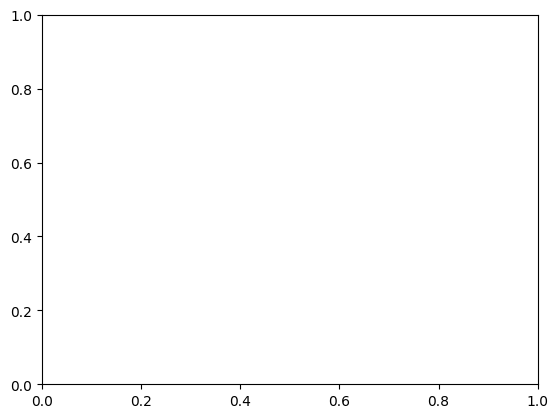

In [169]:
get_all_lines(df_minx,df_out,plt_name)

#find_pathline(df_out, tx,ty,tz,0.003,500,34.1e-6)
#len(pathline_dict)


In [146]:
find_pathline(df_out, 6.581299e-02,6.887207e-03,2.221680e-04,0.0035,500,34.1e-6)

[{1137619: 0.1250000146286403,
  1137620: 0.12500000487625776,
  1137627: 0.12500000487625776,
  1137628: 0.12499999512387673,
  3389395: 0.12500000487612248,
  1137876: 0.12499999512374148,
  3389403: 0.12499999512374148,
  3389404: 0.12499998537136198},
 {1137619: 0.054030660931219984,
  2437849: 0.10729891363754307,
  1137627: 0.08239819567025403,
  1137875: 0.09701905647398064,
  1137883: 0.25410172794090086},
 {1137874: 0.051154338541864554,
  3389394: 0.051154338541864554,
  1137882: 0.3616092347898153,
  3389650: 0.029358961920795804,
  1138130: 0.029358961920795804,
  3389658: 0.057877464747524324},
 {1137881: 0.18452766225651238,
  3389409: 0.06735716900377539,
  1137889: 0.06735716900377539,
  3389657: 0.18120574092877156,
  1138137: 0.18120574092877156,
  1138145: 0.06690942781094061,
  3389665: 0.06690942781094061},
 {1138136: 0.23208819548618206,
  3389656: 0.23208819548618206,
  1138144: 0.15374730315528393,
  3389664: 0.15374730315528393,
  1138392: 0.04351341125587266,


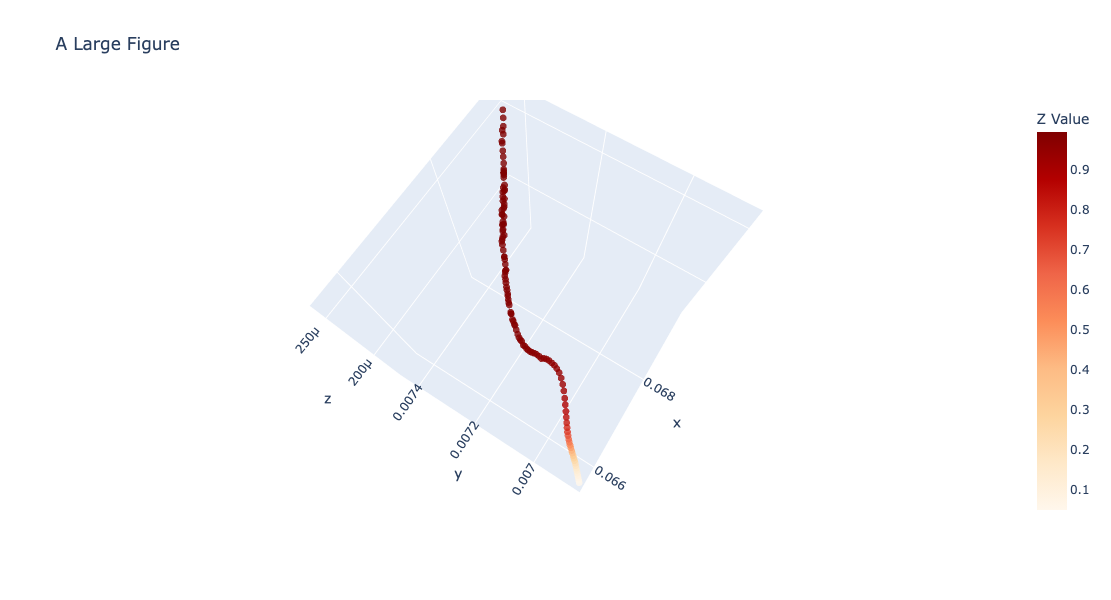

In [37]:
import plotly.express as px
import pandas as pd

# Load sample data (e.g., the Iris dataset)
# df = px.data.iris() 




import plotly.graph_objects as go

fig = go.Figure()

fig = go.Figure(data=[go.Scatter3d(
    x=result_df['x'], 
    y=result_df['y'], 
    z=result_df['z'], 
    mode='markers',
    marker=dict(
        size=4,
        color=result_df['c'],            # Set color to an array of values
        colorscale='OrRd', # Choose a colorscale (e.g., 'Viridis', 'Jet', 'Blues')
        opacity=0.8,
        colorbar=dict(title='Z Value') # Add a color bar
    )
)])

"""
for i in range(len(pathline)):
    fig.add_trace(go.Scatter3d(
        x=[result_df['x'].iloc[i]],
        y=[result_df['y'].iloc[i]],
        z=[result_df['z'].iloc[i]],
        mode='markers+text',
        
        
        textposition='top center',
        marker=dict(size=5,
                    color=result_df['c'].iloc[i],
                    colorscale='OrRd',
                   )
    ))
"""
fig.update_layout(
    width=800,
    height=600,
    title_text="A Large Figure"   # <- key line (1:1:1 scaling)
)



fig.show()

In [74]:
df_350_unique.shape[0]

534

In [76]:
len(df_350_unique['x'].unique())


534

In [19]:
0.06632568359374999/0.000034

1950.7553998161761

In [57]:
0.06634277343749999/0.000034


1951.2580422794115

In [7]:

header_list

['Y(H)',
 'Y(H2)',
 'Y(H2O)',
 'Y(H2O2)',
 'Y(HO2)',
 'Y(N2)',
 'Y(O)',
 'Y(O2)',
 'Y(OH)']

In [8]:
ds.field_list

[('boxlib', 'FunctCall'),
 ('boxlib', 'HeatRelease'),
 ('boxlib', 'I_R(H)'),
 ('boxlib', 'I_R(H2)'),
 ('boxlib', 'I_R(H2O)'),
 ('boxlib', 'I_R(H2O2)'),
 ('boxlib', 'I_R(HO2)'),
 ('boxlib', 'I_R(N2)'),
 ('boxlib', 'I_R(O)'),
 ('boxlib', 'I_R(O2)'),
 ('boxlib', 'I_R(OH)'),
 ('boxlib', 'RhoRT'),
 ('boxlib', 'Y(H)'),
 ('boxlib', 'Y(H2)'),
 ('boxlib', 'Y(H2O)'),
 ('boxlib', 'Y(H2O2)'),
 ('boxlib', 'Y(HO2)'),
 ('boxlib', 'Y(N2)'),
 ('boxlib', 'Y(O)'),
 ('boxlib', 'Y(O2)'),
 ('boxlib', 'Y(OH)'),
 ('boxlib', 'avg_pressure'),
 ('boxlib', 'density'),
 ('boxlib', 'divu'),
 ('boxlib', 'gradpx'),
 ('boxlib', 'gradpy'),
 ('boxlib', 'gradpz'),
 ('boxlib', 'mag_vort'),
 ('boxlib', 'rhoh'),
 ('boxlib', 'temp'),
 ('boxlib', 'x_velocity'),
 ('boxlib', 'y_velocity'),
 ('boxlib', 'z_velocity')]